# SEIS 766: Vision AI (SP26)
## Final Project: Latent Space Traversal
Dante Razo, razo3843@stthomas.edu

In [1]:
from typing import Optional

# set seed for reproducibility
# seed: Optional[int] = 42
seed: Optional[int] = None

## Configuring Environment for GPU Acceleration

In [2]:
from torch import device as torch_device
from torch import cuda

# select device and verify CUDA visibility
device: torch_device = torch_device(device="cuda" if cuda.is_available() else "cpu")
if device.type != "cuda":
    raise RuntimeError("CUDA not detected!")

# log hardware info
print(
    f"Using {str(object=device).upper()} on {cuda.get_device_name(device=cuda.current_device())}"
)

Using CUDA on NVIDIA GeForce RTX 5090


In [3]:
from os import environ

# configure keras
environ["KERAS_BACKEND"] = "torch"
environ["KERAS_TORCH_DEVICE"] = "cuda"

# reduce verbosity
enable_cuda_debug_blocking: bool = False
if enable_cuda_debug_blocking:
    environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [4]:
# check driver and GPU status
!uname -a && echo
!nvidia-smi

Linux ovedur 6.6.87.2-microsoft-standard-WSL2 #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025 x86_64 x86_64 x86_64 GNU/Linux

Sat Apr 25 21:39:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.04              Driver Version: 596.21         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:0A:00.0  On |                  N/A |
| 30%   40C    P0             78W /  460W |    3147MiB /  32607MiB |      3%      Default |
|         

In [5]:
from keras import backend

# configure keras for torch support
backend.set_image_data_format(data_format="channels_last")
backend.set_floatx(value="float32")
backend.clear_session()

In [6]:
from keras.mixed_precision import Policy, set_global_policy

# set global precision policy for torch
policy: Policy = Policy(name="float32")
set_global_policy(policy=policy)

# verify global data types / policies
print(f"Compute Data Type: {policy.compute_dtype}")
print(f"Variable Data Type: {policy.variable_dtype}")

Compute Data Type: float32
Variable Data Type: float32


In [7]:
from keras import config as keras_config

# configure keras
print(f"Keras Backend: {str(object=keras_config.backend()).capitalize()}")

Keras Backend: Torch


## Loading Convolutional Neural Networks

In [8]:
from keras.models import Sequential, load_model

# load model into memory
cnn1: Sequential = load_model(
    filepath="CNN/melanoma_cnn_arch1_35epochs.keras", compile=False
)  # type: ignore

# adjust metadata
cnn1.name = "cnn1-shallow"
cnn1.get_layer(name="dense").name = "embedding"
cnn1.get_layer(name="dense_1").name = "output"

# preview architecture
cnn1.summary()

Model: "cnn1-shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# load model into memory
cnn2: Sequential = load_model(
    filepath="CNN/melanoma_cnn_arch2_35epochs.keras", compile=False
)  # type: ignore

# adjust metadata
cnn2.name = "cnn2-deep"
cnn2.get_layer(name="dense_2").name = "embedding"
cnn2.get_layer(name="dense_3").name = "output"

# preview architecture
cnn2.summary()

Model: "cnn2-deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

## Loading Data

In [10]:
from pandas import DataFrame, read_csv

# load ground truth metadata + classes
metadata_df: DataFrame = read_csv(
    filepath_or_buffer="../data/dante/train-ground-truth/ISIC_2020_Training_GroundTruth_v2.csv",
    usecols=["image_name", "target"],
)

# preview df
metadata_df

,image_name,target
0,ISIC_2637011,0
1,ISIC_0015719,0
2,ISIC_0052212,0
3,ISIC_0068279,0
4,ISIC_0074268,0
...,...,...
33121,ISIC_9999134,0
33122,ISIC_9999320,0
33123,ISIC_9999515,0
33124,ISIC_9999666,0


In [11]:
from pathlib import Path


# define data directory
image_root: Path = Path("../data/dante/train/jpg")


# derive new columns
metadata_df["path"] = [  # type: ignore
    image_root / f"{image_name}.jpg" for image_name in metadata_df["image_name"]
]

# preview metadata_df
metadata_df

,image_name,target,path
0,ISIC_2637011,0,../data/dante/train/jpg/ISIC_2637011.jpg
1,ISIC_0015719,0,../data/dante/train/jpg/ISIC_0015719.jpg
2,ISIC_0052212,0,../data/dante/train/jpg/ISIC_0052212.jpg
3,ISIC_0068279,0,../data/dante/train/jpg/ISIC_0068279.jpg
4,ISIC_0074268,0,../data/dante/train/jpg/ISIC_0074268.jpg
...,...,...,...
33121,ISIC_9999134,0,../data/dante/train/jpg/ISIC_9999134.jpg
33122,ISIC_9999320,0,../data/dante/train/jpg/ISIC_9999320.jpg
33123,ISIC_9999515,0,../data/dante/train/jpg/ISIC_9999515.jpg
33124,ISIC_9999666,0,../data/dante/train/jpg/ISIC_9999666.jpg


In [12]:
# display class distribution
metadata_df["target"].value_counts()

target
0    32542
1      584
Name: count, dtype: int64

In [13]:
# filter to only images that exist on disk
filtered_df: DataFrame = metadata_df.loc[
    metadata_df["path"].map(func=Path.is_file)
].copy()

# print sample size reduction, if applicable
reduced_pct: float = (1 - len(filtered_df) / len(metadata_df)) * 100
if reduced_pct > 0:
    print(
        f"Sample size reduced by {reduced_pct:.2f}% "
        f"({len(metadata_df)} -> {len(filtered_df)}) after filtering!"
    )
else:
    print(f"No sample size reduction after filtering! Still {len(filtered_df)}.")

# preview filtered data
filtered_df

No sample size reduction after filtering! Still 33126.


,image_name,target,path
0,ISIC_2637011,0,../data/dante/train/jpg/ISIC_2637011.jpg
1,ISIC_0015719,0,../data/dante/train/jpg/ISIC_0015719.jpg
2,ISIC_0052212,0,../data/dante/train/jpg/ISIC_0052212.jpg
3,ISIC_0068279,0,../data/dante/train/jpg/ISIC_0068279.jpg
4,ISIC_0074268,0,../data/dante/train/jpg/ISIC_0074268.jpg
...,...,...,...
33121,ISIC_9999134,0,../data/dante/train/jpg/ISIC_9999134.jpg
33122,ISIC_9999320,0,../data/dante/train/jpg/ISIC_9999320.jpg
33123,ISIC_9999515,0,../data/dante/train/jpg/ISIC_9999515.jpg
33124,ISIC_9999666,0,../data/dante/train/jpg/ISIC_9999666.jpg


## Preprocessing Data

In [14]:
from numpy import ndarray, asarray, empty
from PIL import Image
from tqdm.auto import tqdm

# derive image dimensions from model input shape
assert cnn1.input_shape == cnn2.input_shape
img_height: int = cnn1.input_shape[1]
img_width: int = cnn1.input_shape[2]


def load_image_batch(paths: list[str]) -> ndarray:
    """Load and preprocess a batch of images."""
    image_batch: ndarray = empty(
        (len(paths), img_height, img_width, 3), dtype=policy.compute_dtype
    )

    # load and process each image (with progress bar)
    for i, path in enumerate(
        iterable=tqdm(paths, desc="Loading & Processing Images", unit="img")
    ):
        with Image.open(fp=path) as img:
            # load image and process image
            img: Image.Image = img.convert("RGB").resize(
                size=(img_width, img_height),
                resample=Image.Resampling.BILINEAR,
            )

            # normalize image and insert into batch
            image_batch[i] = asarray(a=img, dtype=policy.compute_dtype) / 255.0

    # return batch
    return image_batch

## Helper Functions for Data

In [15]:
def filter_by_class(working_df: DataFrame, target: int) -> DataFrame:
    """Helper function to filter a DataFrame by the given class."""

    return working_df[working_df["target"] == target]

In [16]:
from torch import Tensor


def build_latent_df(
    encoder,
    images_batch: Tensor,
    input_df: DataFrame,
    predict_batch_size: int = 512,
) -> DataFrame:
    """Build a DataFrame of latent vectors with metadata for a given encoder and input batch."""

    # assemble metadata
    names: list[str] = input_df["image_name"].tolist()
    paths: list[str] = input_df["path"].tolist()

    # assemble classes
    targets: ndarray = input_df["target"].to_numpy()

    # generate latent vectors for batch
    z_batch: ndarray = encoder.predict(
        x=images_batch,
        verbose=0,
        batch_size=min(predict_batch_size, len(input_df)),
    )

    # convert ndarray to DF
    latent_df = DataFrame(data=z_batch, index=names)

    # adjust metadata
    latent_df.index.name = "image_name"
    latent_df.columns = [f"z{i:03d}" for i in range(latent_df.shape[1])]
    latent_df.insert(loc=0, column="target", value=targets)
    latent_df.insert(loc=1, column="path", value=paths)

    return latent_df


## Defining Convolutional Neural Network Encoders

In [17]:
from keras import Model

# instantiate encoder for first CNN
cnn1_encoder = Model(
    inputs=cnn1.inputs,
    outputs=cnn1.get_layer(name="embedding").output,
    name="cnn1_encoder",
)

# set trainable flag
cnn1_encoder.trainable = False

# preview architecture
cnn1_encoder.summary()

Model: "cnn1_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │         8,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,712 (108.25 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 27,712 (108.25 KB)

In [18]:
# instantiate encoder for second CNN
cnn2_encoder = Model(
    inputs=cnn2.inputs,
    outputs=cnn2.get_layer(name="embedding").output,
    name="cnn2_encoder",
)

# set trainable flag
cnn2_encoder.trainable = False

# preview architecture
cnn2_encoder.summary()

Model: "cnn2_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,760 (428.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 109,760 (428.75 KB)

## Representing Images in Latent Space

In [19]:
# define sample size (smaller -> faster loading and processing)
sample_size: int = 256

# select N random samples
sampled_df: DataFrame = filtered_df.sample(
    n=sample_size, random_state=seed
).reset_index(drop=False)

# preview sampled DF shape
sampled_df.shape

(256, 4)

In [20]:
# load common data into memory
paths: list[str] = sampled_df["path"].tolist()
batch_paths: ndarray = load_image_batch(paths=paths)


Loading & Processing Images:   0%|          | 0/256 [00:00<?, ?img/s]

In [21]:
from torch import from_numpy

# move data to GPU
images_tensor: Tensor = from_numpy(batch_paths).to(device=device)

In [22]:
# build latent DataFrame for first CNN
cnn1_latent_df: DataFrame = build_latent_df(
    encoder=cnn1_encoder, images_batch=images_tensor, input_df=sampled_df
)

# preview latent df
cnn1_latent_df

,target,path,z000,z001,z002,z003,z004,z005,z006,z007,...,z118,z119,z120,z121,z122,z123,z124,z125,z126,z127
image_name,,,,,,,,,,,,,,,,,,,,,
ISIC_7654211,0,../data/dante/train/jpg/ISIC_7654211.jpg,0.092600,0.0,0.335530,0.0,0.0,0.111310,0.0,0.0,...,0.0,0.0,0.653750,0.0,0.0,0.0,0.0,0.0,0.0,0.663938
ISIC_4597914,0,../data/dante/train/jpg/ISIC_4597914.jpg,0.112603,0.0,0.305680,0.0,0.0,0.059035,0.0,0.0,...,0.0,0.0,0.566335,0.0,0.0,0.0,0.0,0.0,0.0,0.559699
ISIC_4276014,0,../data/dante/train/jpg/ISIC_4276014.jpg,0.110068,0.0,0.398871,0.0,0.0,0.147364,0.0,0.0,...,0.0,0.0,0.744663,0.0,0.0,0.0,0.0,0.0,0.0,0.748204
ISIC_4059746,0,../data/dante/train/jpg/ISIC_4059746.jpg,0.107767,0.0,0.420629,0.0,0.0,0.173345,0.0,0.0,...,0.0,0.0,0.793205,0.0,0.0,0.0,0.0,0.0,0.0,0.799956
ISIC_4345114,0,../data/dante/train/jpg/ISIC_4345114.jpg,0.099708,0.0,0.395895,0.0,0.0,0.159106,0.0,0.0,...,0.0,0.0,0.762798,0.0,0.0,0.0,0.0,0.0,0.0,0.775671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ISIC_0740716,0,../data/dante/train/jpg/ISIC_0740716.jpg,0.088985,0.0,0.305825,0.0,0.0,0.090426,0.0,0.0,...,0.0,0.0,0.597934,0.0,0.0,0.0,0.0,0.0,0.0,0.602092
ISIC_6070930,0,../data/dante/train/jpg/ISIC_6070930.jpg,0.092939,0.0,0.300572,0.0,0.0,0.082882,0.0,0.0,...,0.0,0.0,0.586141,0.0,0.0,0.0,0.0,0.0,0.0,0.585450
ISIC_8417873,1,../data/dante/train/jpg/ISIC_8417873.jpg,0.099691,0.0,0.346904,0.0,0.0,0.115364,0.0,0.0,...,0.0,0.0,0.665412,0.0,0.0,0.0,0.0,0.0,0.0,0.668729


In [23]:
# build latent DataFrame for second CNN
cnn2_latent_df: DataFrame = build_latent_df(
    encoder=cnn2_encoder, images_batch=images_tensor, input_df=sampled_df
)

# preview latent df
cnn2_latent_df

,target,path,z000,z001,z002,z003,z004,z005,z006,z007,...,z118,z119,z120,z121,z122,z123,z124,z125,z126,z127
image_name,,,,,,,,,,,,,,,,,,,,,
ISIC_7654211,0,../data/dante/train/jpg/ISIC_7654211.jpg,0.000000,0.178861,0.136443,0.000000,0.001316,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_4597914,0,../data/dante/train/jpg/ISIC_4597914.jpg,0.000000,0.048127,0.000000,0.000000,0.067651,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_4276014,0,../data/dante/train/jpg/ISIC_4276014.jpg,0.576744,0.726282,0.442830,0.061629,0.083568,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_4059746,0,../data/dante/train/jpg/ISIC_4059746.jpg,0.761399,0.967961,0.725091,0.068436,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.021484,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_4345114,0,../data/dante/train/jpg/ISIC_4345114.jpg,0.525020,0.761401,0.646289,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.072974,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ISIC_0740716,0,../data/dante/train/jpg/ISIC_0740716.jpg,0.000000,0.059687,0.000000,0.000000,0.025574,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_6070930,0,../data/dante/train/jpg/ISIC_6070930.jpg,0.000000,0.091963,0.000000,0.000000,0.047279,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ISIC_8417873,1,../data/dante/train/jpg/ISIC_8417873.jpg,0.178596,0.342518,0.206191,0.000000,0.054776,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


## Defining Convolutional Neural Network Decoders

In [24]:
from keras import Input
from keras.layers import Dense, Reshape, Conv2D, UpSampling2D


def build_decoder(
    latent_dim=128, start_shape=(14, 14, 128), out_channels=3, name="decoder"
) -> Model:
    """Manually define decoder"""
    h, w, c = start_shape

    # input layer
    latent_inputs = Input(shape=(latent_dim,), name="latent_input")
    input: Dense = Dense(units=h * w * c, activation="relu")(latent_inputs)
    reshaped: Reshape = Reshape(target_shape=(h, w, c))(input)

    # hidden layers
    dense1: UpSampling2D = UpSampling2D(size=2)(reshaped)
    dense2: Conv2D = Conv2D(
        filters=128, kernel_size=3, padding="same", activation="relu"
    )(dense1)

    dense3: UpSampling2D = UpSampling2D(size=2)(dense2)
    dense4: Conv2D = Conv2D(
        filters=64, kernel_size=3, padding="same", activation="relu"
    )(dense3)

    dense3: UpSampling2D = UpSampling2D(size=2)(dense4)
    dense4: Conv2D = Conv2D(
        filters=32, kernel_size=3, padding="same", activation="relu"
    )(dense3)

    dense5: UpSampling2D = UpSampling2D(size=2)(dense4)
    dense6: Conv2D = Conv2D(
        filters=16, kernel_size=3, padding="same", activation="relu"
    )(dense5)

    # output layer
    outputs: Conv2D = Conv2D(
        filters=out_channels,
        kernel_size=3,
        padding="same",
        activation="sigmoid",
        name="reconstruction",
    )(dense6)

    return Model(latent_inputs, outputs, name=name)


def build_autoencoder(encoder, decoder, name="autoencoder") -> Model:
    """Given encoder and decoder, build an autoencoder"""
    return Model(encoder.input, decoder(encoder.output), name=name)

In [25]:
# build decoders
cnn1_decoder: Model = build_decoder(latent_dim=128, name="cnn1_decoder")
cnn2_decoder: Model = build_decoder(latent_dim=128, name="cnn2_decoder")

In [26]:
from numpy import ceil

# define common autoencoder hyperparameters
epochs: int = 150
batch_size: int = int(ceil(sample_size / 8))  # scales with sample size

# set fit parameters
validation_split: float = 0.2
early_stopping_patience: int = 10
reduce_lr_patience: int = 5

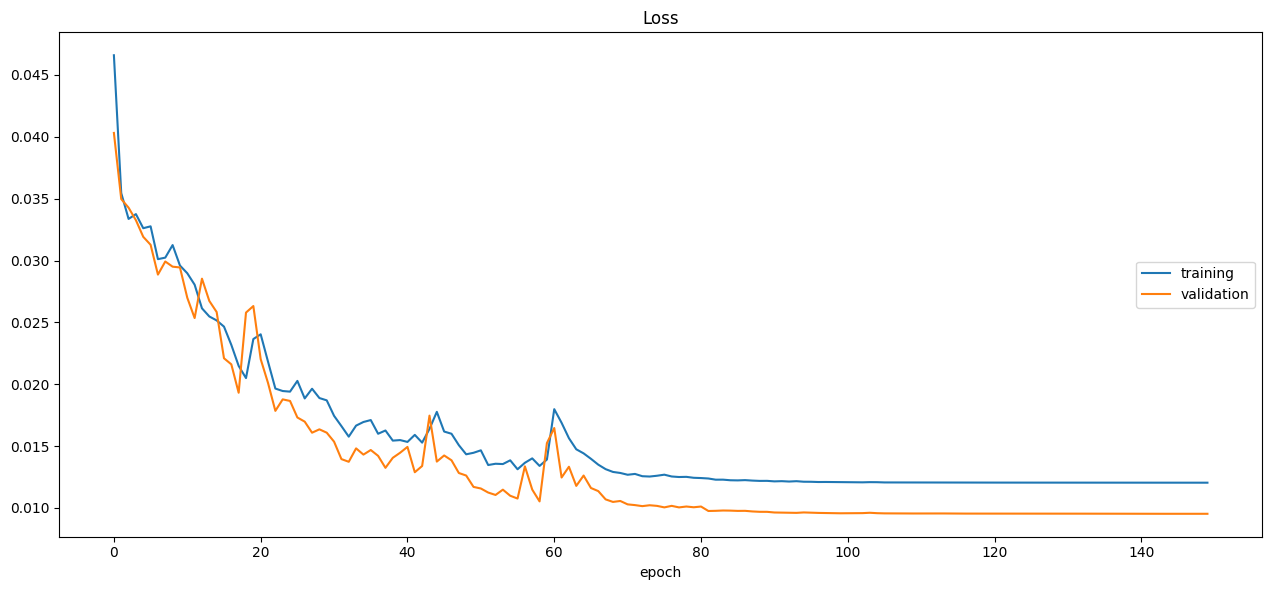

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0120 - val_loss: 0.0095 - learning_rate: 1.0000e-06
Restoring model weights from the end of the best epoch: 150.


In [27]:
from keras.callbacks import History, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from livelossplot import PlotLossesKeras
from typing import Any
from livelossplot.outputs import MatplotlibPlot


# build autoencoder for CNN1
cnn1_ae: Model = build_autoencoder(
    encoder=cnn1_encoder, decoder=cnn1_decoder, name="cnn1_ae"
)


# define optimizer & compile autoencoder
cnn1_ae.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")

# define callbacks
cnn1_callbacks: list[Any] = [
    PlotLossesKeras(outputs=[MatplotlibPlot(figsize=(25, 6))]),
    EarlyStopping(
        monitor="val_loss",
        patience=early_stopping_patience,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=reduce_lr_patience,
        min_lr=1e-6,
        verbose=1,
    ),
]

# fit autoencoder
cnn1_history: History = cnn1_ae.fit(
    x=images_tensor,
    y=images_tensor,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    callbacks=cnn1_callbacks,
    shuffle=True,
)

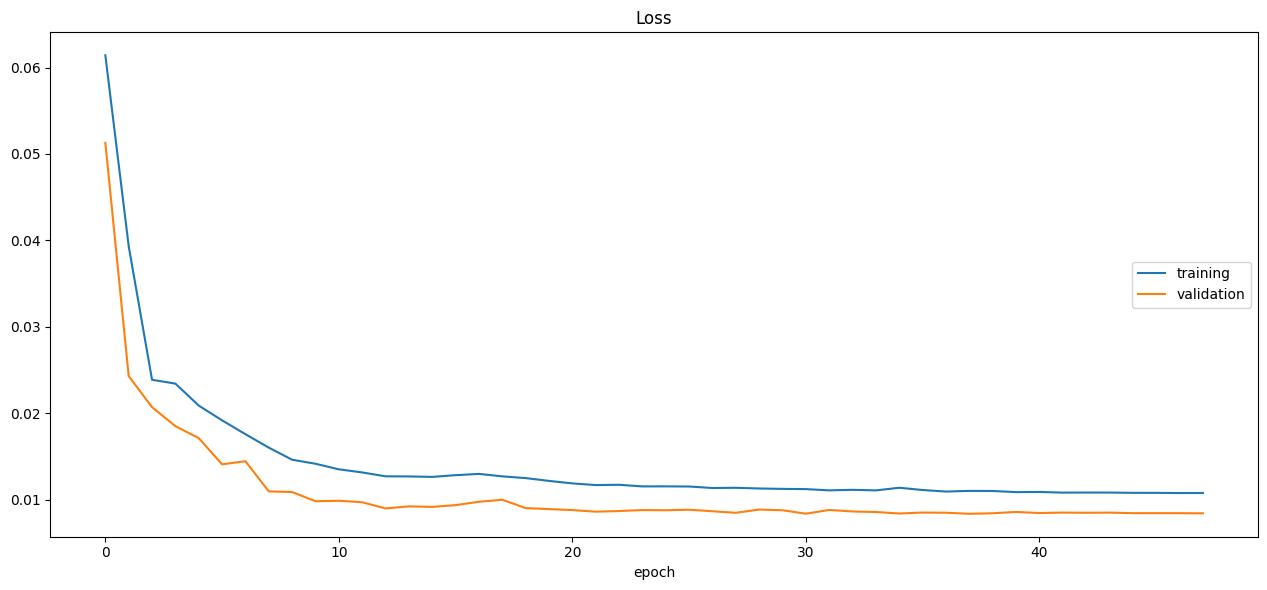

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0108 - val_loss: 0.0084 - learning_rate: 3.1250e-05
Epoch 48: early stopping
Restoring model weights from the end of the best epoch: 38.


In [28]:
# build autoencoder for CNN2
cnn2_ae: Model = build_autoencoder(
    encoder=cnn2_encoder, decoder=cnn2_decoder, name="cnn2_ae"
)

# compile autoencoder
cnn2_ae.compile(optimizer="adam", loss="mse")

# define callbacks
cnn2_callbacks: list[Any] = [
    PlotLossesKeras(outputs=[MatplotlibPlot(figsize=(25, 6))]),
    EarlyStopping(
        monitor="val_loss",
        patience=early_stopping_patience,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=reduce_lr_patience,
        min_lr=1e-6,
        min_delta=1e-4,
        verbose=1,
    ),
]

# fit autoencoder
cnn2_history: History = cnn2_ae.fit(
    x=images_tensor,
    y=images_tensor,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    callbacks=cnn2_callbacks,
    shuffle=True,
)

## Helper Functions for Latent Space Traversal

In [29]:
from numpy import linspace
from numpy.linalg import norm


def interpolate_latents(z_start, z_end, steps=10):
    alphas: ndarray = linspace(start=0.0, stop=1.0, num=steps, dtype=float)[:, None]

    return (1.0 - alphas) * z_start[None, :] + alphas * z_end[None, :]


# TODO: better typing, returns, etc.
def walk_latent_pairs(latent_df, decoder, pair_indices, steps=10):
    latent_cols = [c for c in latent_df.columns if c.startswith("z")]
    walks = []
    meta_rows = []

    for pair_id, (i, j) in enumerate(pair_indices):
        row_a = latent_df.iloc[i]
        row_b = latent_df.iloc[j]

        z_a = row_a[latent_cols].to_numpy(dtype=policy.compute_dtype)
        z_b = row_b[latent_cols].to_numpy(dtype=policy.compute_dtype)
        z_path = interpolate_latents(z_start=z_a, z_end=z_b, steps=steps)
        total_latent_l2: float = float(norm(z_b - z_a))

        decoded = decoder.predict(
            z_path,
            verbose=0,
            batch_size=min(batch_size, len(z_path)),
        )

        walks.append(decoded)

        for step, alpha in enumerate(
            linspace(start=0.0, stop=1.0, num=steps, dtype=policy.compute_dtype)
        ):
            meta_rows.append(
                {
                    "pair_id": pair_id,
                    "step": step,
                    "alpha": float(alpha),
                    "start_name": latent_df.index[i],
                    "end_name": latent_df.index[j],
                    "start_class": int(row_a["target"]),
                    "end_class": int(row_b["target"]),
                    "total_latent_l2": total_latent_l2,
                }
            )

    return walks, DataFrame(data=meta_rows)

In [30]:
# number of pairs to walk between
n: int = 1


# assemble pairs
pair_indices: list[tuple[int, int]] = [(i, i + 1) for i in range(0, n * 2, 2)]

In [31]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
from matplotlib.offsetbox import TextArea, HPacker, AnchoredOffsetbox

from numpy import clip


# define colors
@dataclass
class PlotColors:
    BASE: str = "#222222"
    IMAGE: str = "#4B2E83"
    ALPHA: str = "#9A6A2F"
    CLASS: str = "#8C5A1E"
    L2: str = "#5C5C5C"


def plot_walk(
    latent_df: DataFrame, decoder: Model, steps: int = 10, target: Optional[int] = None
) -> None:
    # conditional assignment
    if target:
        latent_df = filter_by_class(working_df=latent_df, target=target)

    # TODO: ensure different classes

    walks, walk_meta = walk_latent_pairs(
        latent_df=latent_df,
        decoder=decoder,
        pair_indices=pair_indices,
        steps=steps,
    )

    for i, imgs in enumerate(walks):
        # retrieve metadata for walk
        meta: DataFrame = walk_meta[walk_meta["pair_id"] == i].reset_index(drop=True)

        # extract metadata for walk
        start_name: str = str(meta.loc[0, "start_name"])
        end_name: str = str(meta.loc[0, "end_name"])
        start_class: int = int(meta.loc[0, "start_class"])  # type: ignore
        end_class: int = int(meta.loc[0, "end_class"])  # type: ignore
        total_latent_l2: float = float(meta.loc[0, "total_latent_l2"])  # type: ignore
        alphas: ndarray = meta["alpha"].to_numpy()
        step_nums: ndarray = meta["step"].to_numpy()

        fig, axes = plt.subplots(
            nrows=1, ncols=len(imgs), figsize=(2.5 * len(imgs), 3.5)
        )

        if len(imgs) == 1:
            axes = [axes]

        for j, (ax, img, alpha, step_num) in enumerate(
            zip(axes, imgs, alphas, step_nums)
        ):
            ax.imshow(clip(img, 0, 1))
            ax.set_title(
                f"Step {step_num + 1}",
                fontsize=13,
                pad=24,
                fontweight="medium",
            )

            ax.text(
                0.5,
                1.06,
                f"α = {alpha:.3f}",
                transform=ax.transAxes,
                ha="center",
                va="bottom",
                fontsize=12,
                fontstyle="italic",
                color=PlotColors.ALPHA,
            )

            label: str = ""
            if j == 0:
                label = f"{start_name}\n(Start)"
            elif j == len(imgs) - 1:
                label = f"{end_name}\n(End)"

            ax.set_xlabel(
                label,
                fontsize=9,
                labelpad=8,
                fontweight="semibold",
                color="#380082",
            )
            ax.set_xticks([])
            ax.set_yticks([])

        # define multi-color title
        title_style: str = "italic"
        title_parts = [
            TextArea(
                s="Walking from ",
                textprops=dict(
                    color=PlotColors.BASE,
                    fontsize=16,
                    fontweight="semibold",
                    style=title_style,
                ),
            ),
            TextArea(
                s=start_name.strip(),
                textprops=dict(
                    color=PlotColors.IMAGE,
                    fontsize=16,
                    fontweight="semibold",
                    style=title_style,
                ),
            ),
            TextArea(
                s=f"(c{start_class}) ",
                textprops=dict(
                    color=PlotColors.CLASS,
                    fontsize=16,
                    fontweight="semibold",
                    style=title_style,
                ),
            ),
            TextArea(
                s="to ",
                textprops=dict(
                    color=PlotColors.BASE,
                    fontsize=16,
                    fontweight="semibold",
                    style=title_style,
                ),
            ),
            TextArea(
                s=end_name.strip(),
                textprops=dict(
                    color=PlotColors.IMAGE,
                    fontsize=16,
                    fontweight="semibold",
                    style=title_style,
                ),
            ),
            TextArea(
                s=f"(c{end_class})",
                textprops=dict(
                    color=PlotColors.CLASS,
                    fontsize=16,
                    fontweight="semibold",
                    style=title_style,
                ),
            ),
        ]

        title_box: HPacker = HPacker(children=title_parts, align="center", pad=0, sep=2)  # type: ignore

        anchored_title: AnchoredOffsetbox = AnchoredOffsetbox(
            loc="upper center",
            child=title_box,
            pad=0.0,
            borderpad=0.0,
            frameon=False,
            bbox_to_anchor=(0.5, 1.02),
            bbox_transform=fig.transFigure,
        )

        fig.add_artist(artist=anchored_title)

        fig.text(
            x=0.5,
            y=0.04,
            s=f"L2 Distance = {total_latent_l2:.3f}",
            ha="center",
            va="bottom",
            fontsize=12,
            color=PlotColors.L2,
            fontweight="medium",
        )

        # plt.tight_layout()
        plt.show()

## Walking Between Images in Latent Space

In [32]:
# define common walk hyperparameters
steps: int = 10

### CNN Architecture #1: Class 0 (Benign)

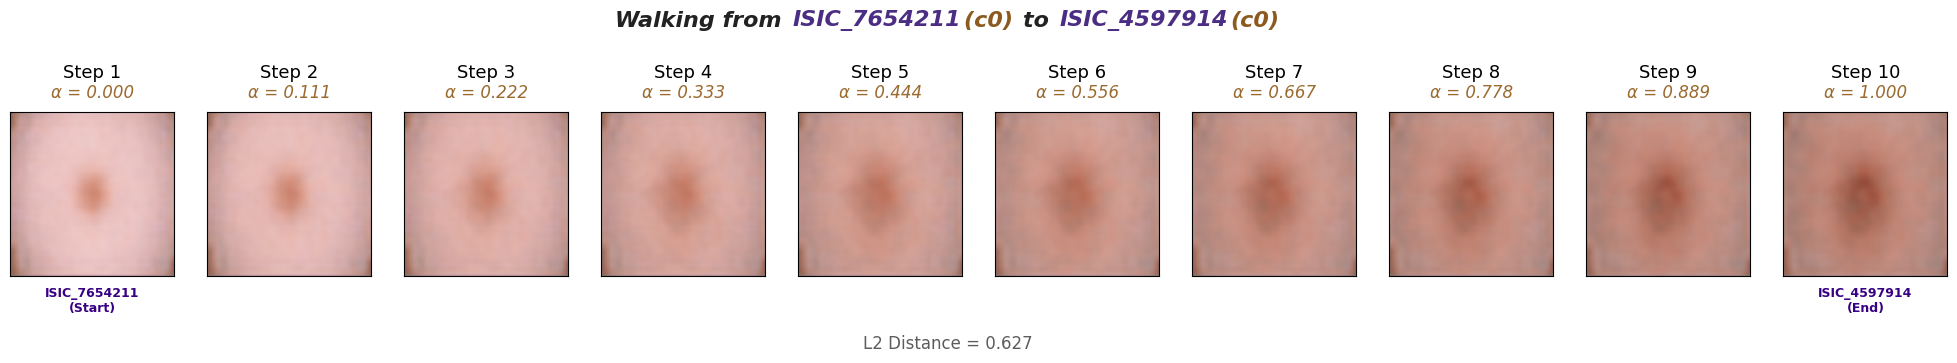

In [33]:
plot_walk(latent_df=cnn1_latent_df, decoder=cnn1_decoder, steps=steps, target=0)

### CNN Architecture #1: Class 1 (Malignant)

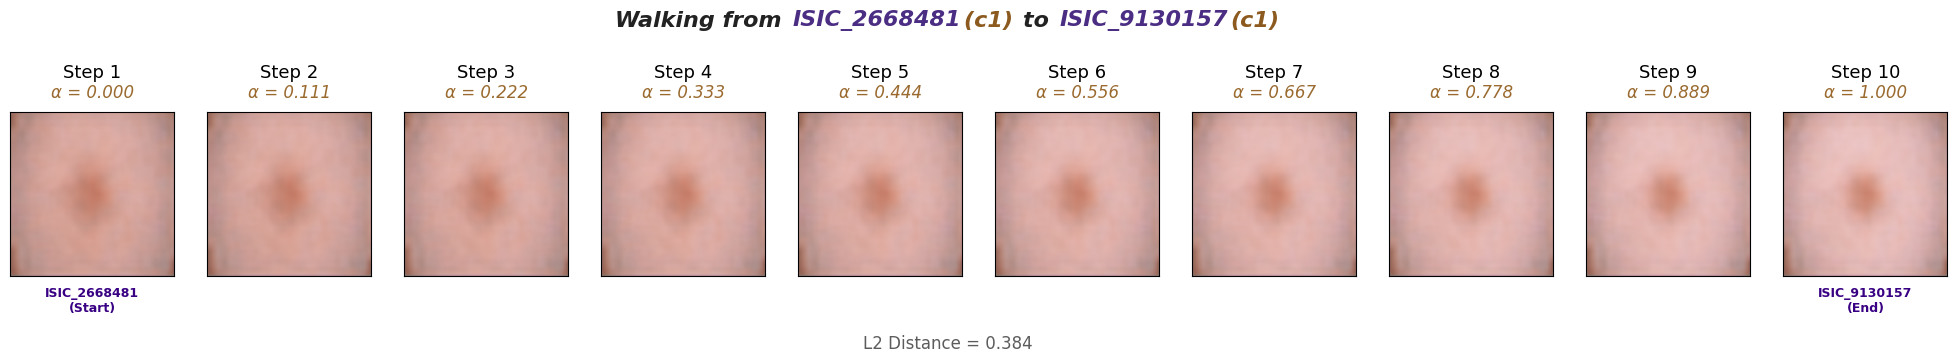

In [34]:
plot_walk(latent_df=cnn1_latent_df, decoder=cnn1_decoder, steps=steps, target=1)

### CNN Architecture #1: Between Classes

In [35]:
# TODO: walk between class0 and class1
# plot_walk(latent_df=cnn1_latent_df, decoder=cnn1_decoder, steps=steps, target=None)

### CNN Architecture #2: Class 0 (Benign)

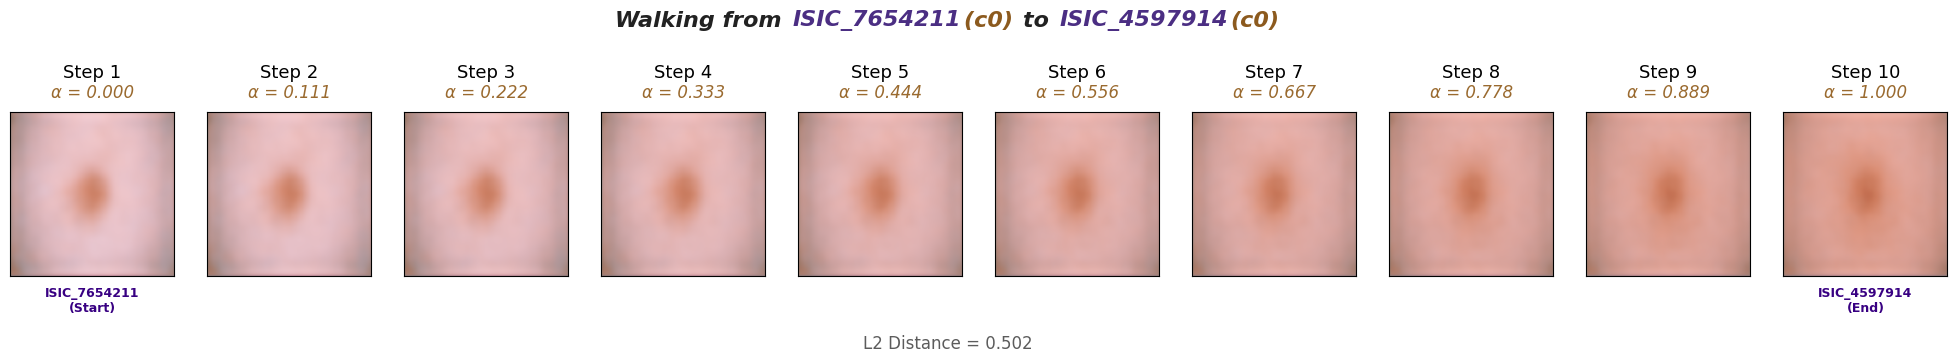

In [36]:
plot_walk(latent_df=cnn2_latent_df, decoder=cnn2_decoder, steps=steps, target=0)

### CNN Architecture #2: Class 1 (Malignant)

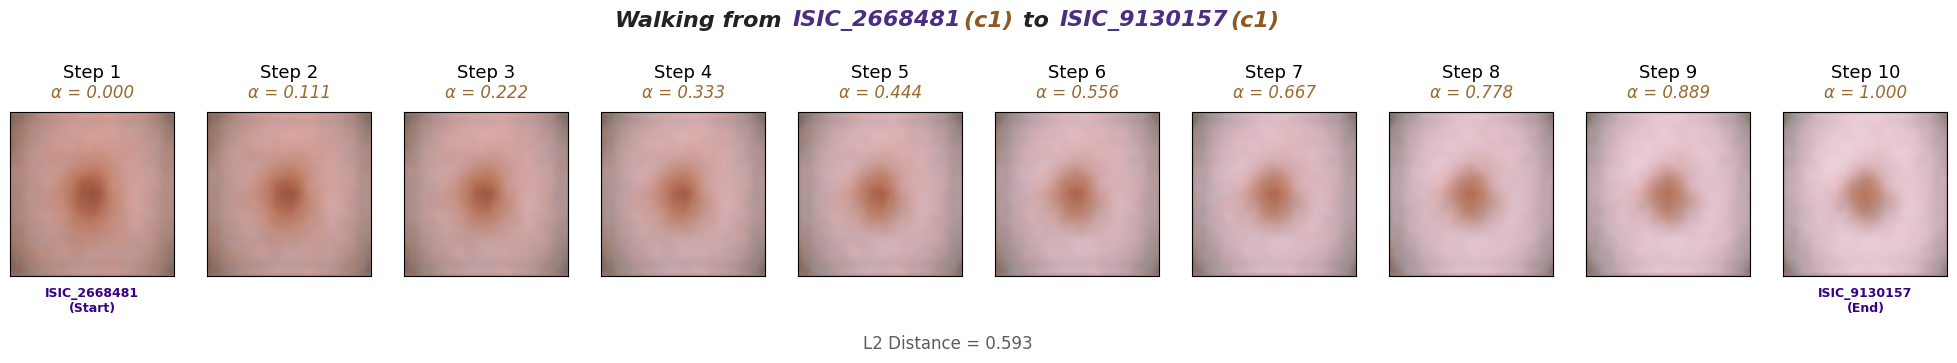

In [37]:
plot_walk(latent_df=cnn2_latent_df, decoder=cnn2_decoder, steps=steps, target=1)

### CNN Architecture #2: Between Classes

In [38]:
# TODO: walk between class0 and class1
# plot_walk(latent_df=cnn2_latent_df, decoder=cnn2_decoder, steps=steps, target=None)